# Personalized Product Ad Composer

## 1. Problem Understanding
Develop an AI-powered system that generates personalized product advertisements including images and marketing text based on product details and target audience details.

### Project Requirements:
- **Objective**: Generate Headline, Description, Slogan, and Promotional Image.
- **Inputs**: Product Name, Category, Target Demographic.
- **Demographic Styles**:
    - **Teenagers**: Trendy, energetic, bold colors, playful tone.
    - **Professionals**: Minimalistic, premium, confident tone.
    - **Seniors**: Calm, trustworthy, simple tone.

## 2. Data Collection
We use the Flipkart Ecommerce Sample dataset to source product information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json

# Load dataset
try:
    df = pd.read_csv('../flipkart_com-ecommerce_sample.csv')
    print(f"Dataset Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please ensure 'flipkart_com-ecommerce_sample.csv' is in the current directory.")

Dataset Shape: (20000, 15)


## 3. Data Cleaning & Preprocessing

A comprehensive step-by-step pipeline to clean the raw Flipkart data and prepare it for ad generation.

**Steps covered:**
- **3.1** Extract Main Category from Category Tree
- **3.2** Select Relevant Columns & Drop Missing Values
- **3.3** Remove Duplicate Rows
- **3.4** Normalize Text (strip whitespace, fix casing)
- **3.5** Clean Description (remove HTML/special chars, filter short texts)
- **3.6** Clean Brand Column
- **3.7** Final Summary & Preview


### Step 3.1 — Extract Main Category from Category Tree

In [2]:
def clean_category(cat_tree):
    """Extract the top-level category from Flipkart's nested category tree.
    Example: '["Clothing >> T-Shirts >> Men"]' -> 'Clothing'
    """
    try:
        main_cat = re.sub(r'[\[\]"]', '', str(cat_tree)).split('>>')[0].strip()
        return main_cat if main_cat else 'General'
    except:
        return 'General'

df['main_category'] = df['product_category_tree'].apply(clean_category)
print(f'Unique main categories found: {df["main_category"].nunique()}')
print(df['main_category'].value_counts().head(10))

Unique main categories found: 265
main_category
Clothing                      6198
Jewellery                     3531
Footwear                      1227
Mobiles & Accessories         1099
Automotive                    1012
Home Decor & Festive Needs     929
Beauty and Personal Care       710
Home Furnishing                700
Kitchen & Dining               647
Computers                      578
Name: count, dtype: int64


### Step 3.2 — Select Relevant Columns & Drop Missing Values

In [3]:
# Keep only the four columns needed for ad generation
columns_needed = ['product_name', 'main_category', 'description', 'brand']
df_clean = df[columns_needed].dropna(subset=['product_name', 'main_category', 'description']).copy()

print(f'Rows before dropping NaN : {len(df):,}')
print(f'Rows after  dropping NaN : {len(df_clean):,}')
df_clean.head()

Rows before dropping NaN : 20,000
Rows after  dropping NaN : 19,998


,product_name,main_category,description,brand
0,Alisha Solid Women's Cycling Shorts,Clothing,Key Features of Alisha Solid Women's Cycling S...,Alisha
1,FabHomeDecor Fabric Double Sofa Bed,Furniture,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,FabHomeDecor
2,AW Bellies,Footwear,Key Features of AW Bellies Sandals Wedges Heel...,AW
3,Alisha Solid Women's Cycling Shorts,Clothing,Key Features of Alisha Solid Women's Cycling S...,Alisha
4,Sicons All Purpose Arnica Dog Shampoo,Pet Supplies,Specifications of Sicons All Purpose Arnica Do...,Sicons


### Step 3.3 — Remove Duplicate Rows

In [4]:
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Duplicate rows removed : {rows_before - len(df_clean):,}')
print(f'Rows remaining         : {len(df_clean):,}')

Duplicate rows removed : 2,392
Rows remaining         : 17,606


### Step 3.4 — Normalize Text (Strip Whitespace & Fix Casing)

In [5]:
# Strip leading/trailing whitespace
for col in ['product_name', 'main_category', 'brand']:
    df_clean[col] = df_clean[col].str.strip()

# Consistent title-casing
df_clean['product_name']  = df_clean['product_name'].str.title()
df_clean['brand']         = df_clean['brand'].str.title()
df_clean['main_category'] = df_clean['main_category'].str.title()

print('Text normalization complete.')
df_clean[['product_name', 'brand', 'main_category']].head()

Text normalization complete.


,product_name,brand,main_category
0,Alisha Solid Women'S Cycling Shorts,Alisha,Clothing
1,Fabhomedecor Fabric Double Sofa Bed,Fabhomedecor,Furniture
2,Aw Bellies,Aw,Footwear
3,Alisha Solid Women'S Cycling Shorts,Alisha,Clothing
4,Sicons All Purpose Arnica Dog Shampoo,Sicons,Pet Supplies


### Step 3.5 — Clean Description (Remove HTML/Special Chars & Filter Short Texts)

In [6]:
def clean_description(text):
    """Remove HTML tags, collapse extra whitespace."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)   # strip HTML-like tags
    text = re.sub(r'\s+', ' ', text).strip()  # collapse whitespace
    return text

df_clean['description'] = df_clean['description'].apply(clean_description)

# Drop rows where the cleaned description is shorter than 20 characters
MIN_DESC_LEN = 20
rows_before  = len(df_clean)
df_clean = df_clean[df_clean['description'].str.len() >= MIN_DESC_LEN].reset_index(drop=True)
print(f'Rows removed (description too short) : {rows_before - len(df_clean):,}')
print(f'Rows remaining                       : {len(df_clean):,}')
df_clean['description'].head()

Rows removed (description too short) : 0
Rows remaining                       : 17,606


0    Key Features of Alisha Solid Women's Cycling S...
1    FabHomeDecor Fabric Double Sofa Bed (Finish Co...
2    Key Features of AW Bellies Sandals Wedges Heel...
3    Key Features of Alisha Solid Women's Cycling S...
4    Specifications of Sicons All Purpose Arnica Do...
Name: description, dtype: object

### Step 3.6 — Clean Brand Column

In [7]:
import re

# ─────────────────────────────────────────────────────────────────
# 3.6 Smart Brand Extraction (Improved v2)
# Problem tha: Brand mein 'Black','Red','Slim','Regular' aa rahe the
# Fix: Blacklist se validate karo, galat ho toh product_name se extract karo
# ─────────────────────────────────────────────────────────────────

NOT_A_BRAND = set([
    # Colors
    'black','white','red','blue','green','yellow','orange','purple','pink',
    'grey','gray','brown','navy','gold','silver','cream','beige','maroon',
    'violet','indigo','teal','cyan','magenta','turquoise','coral','peach',
    # Sizes / Fits
    'slim','regular','large','small','medium','xl','xxl','xs','plus','mini',
    # Common adjectives that are NOT brands
    'new','best','top','hot','cool','pro','max','ultra','super','mega',
    'solid','printed','striped','floral','casual','formal','sport',
    'men','women','boys','girls','kids','baby','adult','unisex',
    'pack','set','combo','kit','bundle',
    # Articles / prepositions
    'the','a','an','of','for','and','with','by','in','on','at',
    # E-commerce noise
    'flipkart','amazon','myntra','online','india','branded',
])

def extract_brand_from_name(product_name):
    """Product name ke shuru ke proper nouns se brand dhundta hai."""
    if not product_name or str(product_name).strip().lower() in ['nan','none','']:
        return 'Aura'
    words = str(product_name).strip().split()
    brand_words = []
    for i, word in enumerate(words):
        clean_word = re.sub(r"[^a-zA-Z0-9\-']", '', word)
        if not clean_word:
            break
        # Pehla word blacklisted ho toh brand nahi mila
        if i == 0 and clean_word.lower() in NOT_A_BRAND:
            return 'Aura'
        # Koi bhi word blacklisted ho toh brand yahaan khatam
        if clean_word.lower() in NOT_A_BRAND:
            break
        # Uppercase/alphanumeric = valid brand word
        if re.match(r"^[A-Z0-9][a-zA-Z0-9'\-]*$", clean_word):
            brand_words.append(clean_word)
        else:
            if brand_words:
                break
            return 'Aura'
        # Max 3 words tak brand lo
        if len(brand_words) >= 3:
            break
        # Agla word possessive/descriptor ho toh rok jao
        if i + 1 < len(words):
            next_clean = re.sub(r'[^a-zA-Z0-9]', '', words[i+1])
            if next_clean.lower() in ['mens','womens','boys','girls','kids',
                                       'solid','printed','casual','formal']:
                break
    return ' '.join(brand_words) if brand_words else 'Aura'


def smart_brand_extractor_v2(row):
    """Brand validate karo — color/adjective ho toh product_name se extract karo."""
    raw_brand = str(row.get('brand', '')).strip()
    is_bad = (
        not raw_brand
        or raw_brand.lower() in ['unknown', 'nan', 'na', 'none', '']
        or raw_brand.lower() in NOT_A_BRAND
    )
    if is_bad or len(raw_brand) <= 1:
        return extract_brand_from_name(str(row.get('product_name', '')))
    return raw_brand


df_clean['brand'] = df_clean.apply(smart_brand_extractor_v2, axis=1)

print('Top 20 brands after smart cleaning v2:')
print(df_clean['brand'].value_counts().head(20))
print(f"\nDefault 'Aura' count: {(df_clean['brand'] == 'Aura').sum()}")
print(f"Total rows: {len(df_clean)}")


Top 20 brands after smart cleaning v2:
brand
Allure Auto       469
Voylla            255
Karatcraft        211
Aura              143
Speedwav          140
Radiant Bay       132
Numero Uno        119
Bluestone          98
Adroitz            74
S4S Stylish        73
Regular Fit        68
Dailyobjects       60
Okane              59
Easy Gardening     52
Anuradha Art       51
Oviyon             50
Hotpiper           50
Dressberry         50
Raymond            50
Jewelizer          48
Name: count, dtype: int64

Default 'Aura' count: 143
Total rows: 17606


### Step 3.7 — Final Summary & Preview

In [8]:
print('=== Cleaned Dataset Summary ===')
print(f'Total records : {len(df_clean):,}')
print(f'Columns       : {list(df_clean.columns)}')
print('Missing values per column:')
print(df_clean.isnull().sum())
print()
df_clean.head(10)

=== Cleaned Dataset Summary ===
Total records : 17,606
Columns       : ['product_name', 'main_category', 'description', 'brand']
Missing values per column:
product_name     0
main_category    0
description      0
brand            0
dtype: int64



,product_name,main_category,description,brand
0,Alisha Solid Women'S Cycling Shorts,Clothing,Key Features of Alisha Solid Women's Cycling S...,Alisha
1,Fabhomedecor Fabric Double Sofa Bed,Furniture,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,Fabhomedecor
2,Aw Bellies,Footwear,Key Features of AW Bellies Sandals Wedges Heel...,Aw
3,Alisha Solid Women'S Cycling Shorts,Clothing,Key Features of Alisha Solid Women's Cycling S...,Alisha
4,Sicons All Purpose Arnica Dog Shampoo,Pet Supplies,Specifications of Sicons All Purpose Arnica Do...,Sicons
5,Eternal Gandhi Super Series Crystal Paper Weig...,Eternal Gandhi Super Series Crystal Paper Weig...,Key Features of Eternal Gandhi Super Series Cr...,Eternal Gandhi
6,Alisha Solid Women'S Cycling Shorts,Clothing,Key Features of Alisha Solid Women's Cycling S...,Alisha
7,Fabhomedecor Fabric Double Sofa Bed,Furniture,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,Fabhomedecor
8,"Dilli Bazaaar Bellies, Corporate Casuals, Casuals",Footwear,"Key Features of dilli bazaaar Bellies, Corpora...",Dilli Bazaaar
9,Alisha Solid Women'S Cycling Shorts,Clothing,Key Features of Alisha Solid Women's Cycling S...,Alisha


## 3a. Save & Download Cleaned Dataset

Save the cleaned DataFrame as a CSV file **inside this notebook** and provide a clickable download link.


In [9]:
import os
from IPython.display import FileLink, display as ipy_display

# ── Save ────────────────────────────────────────────────────────────────
CLEAN_CSV_PATH = 'cleaned_product_data.csv'
df_clean.to_csv(CLEAN_CSV_PATH, index=False)

file_size_kb = os.path.getsize(CLEAN_CSV_PATH) / 1024
print(f'✅ Cleaned dataset saved  : {CLEAN_CSV_PATH}')
print(f'   Rows    : {len(df_clean):,}')
print(f'   Columns : {list(df_clean.columns)}')
print(f'   Size    : {file_size_kb:.1f} KB')
print()

# ── Download link (works in Jupyter / JupyterLab) ───────────────────────
print('Click the link below to download the cleaned CSV:')
ipy_display(FileLink(CLEAN_CSV_PATH,
                     result_html_prefix='⬇️  <b>Download cleaned dataset:</b> '))

✅ Cleaned dataset saved  : cleaned_product_data.csv
   Rows    : 17,606
   Columns : ['product_name', 'main_category', 'description', 'brand']
   Size    : 8638.9 KB

Click the link below to download the cleaned CSV:


C:\Users\Shrim\Desktop\Project product ad composer\notebooks\cleaned_product_data.csv

## 4. Exploratory Data Analysis (EDA)
Visualizing our data distributions to understand the product landscape.

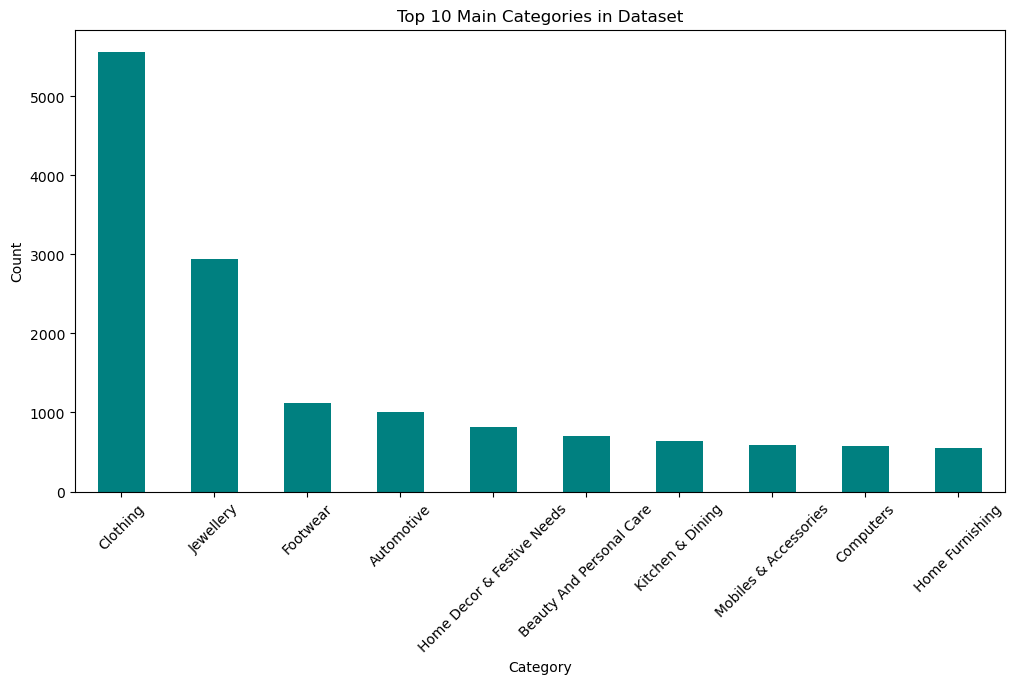

In [10]:
# Plotting the distribution of the Top 10 categories
plt.figure(figsize=(12, 6))
df_clean['main_category'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Main Categories in Dataset')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## 5. Feature Engineering: Demographic Style Mapping
Connecting audience segments to their preferred aesthetic and linguistic tones.

In [11]:
DEMOGRAPHIC_STYLES = {
    "Teenagers": {
        "aesthetic": "Trendy, energetic, bold colors, vibrant pop-art style",
        "tone": "Playful, slang-friendly, high energy",
        "keywords": ["fresh", "viral", "must-have", "lit", "trendy"]
    },
    "Professionals": {
        "aesthetic": "Minimalistic, premium, sophisticated, sleek professional studio lighting",
        "tone": "Confident, concise, authoritative",
        "keywords": ["efficiency", "premium", "success", "reliability", "sleek"]
    },
    "Seniors": {
        "aesthetic": "Calm, trustworthy, warm lighting, simple and clear composition",
        "tone": "Gentle, reassuring, simple, respectful",
        "keywords": ["comfort", "trusted", "easy", "quality", "classic"]
    }
}

def get_style_metadata(demographic):
    return DEMOGRAPHIC_STYLES.get(demographic, DEMOGRAPHIC_STYLES["Professionals"])

## 6. Deployment Strategy
The system can be deployed as an interactive tool using Streamlit.

In [12]:
# Run this snippet in an external .py file to launch the UI
app_code = """
import streamlit as st
st.title('AI-Powered Personalized Ad Composer')
st.write('Input details to generate your curated ad bundle.')
"""
print("Ready for deployment.")

Ready for deployment.


## STEP 7: Machine Learning Audience Classifier

In [13]:
# ==========================================
# STEP 7: Machine Learning Audience Classifier
# ==========================================

import numpy as np
import warnings
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

print("11.1 Creating Synthetic Labels for Training...")
def label_audience(text):
    text = str(text).lower()
    teen_keywords = ['trendy', 'cool', 'fun', 'youth', 'girl', 'boy', 'fashion', 'kids', 'pop', 'vibrant', 'gaming', 'toys', 'casual', 'party']
    senior_keywords = ['comfort', 'medical', 'health', 'classic', 'authentic', 'vintage', 'easy', 'reliable', 'home', 'traditional', 'ayurvedic', 'care']
    
    if any(word in text for word in teen_keywords):
        return 'Teenagers'
    elif any(word in text for word in senior_keywords):
        return 'Seniors'
    else:
        return 'Professionals'

# Create Target Column
df_clean['target_audience'] = df_clean['description'].apply(label_audience)
print(df_clean['target_audience'].value_counts())
print("-" * 40)

print("11.2 Splitting Data (Train/Test) & Creating ML Pipeline...")
X = df_clean['description']
y = df_clean['target_audience']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Transformer + Classifier Pipeline
ml_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english')),
    ('rf_classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("11.3 Training the Machine Learning model (Please wait)...")
ml_pipeline.fit(X_train, y_train)

print("-" * 40)
print("11.4 Classification Report (Evaluating Accuracy):")
y_pred = ml_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print("-" * 40)

print("11.5 Exporting model to .pkl file...")
MODEL_PATH = 'audience_predictor.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(ml_pipeline, f)

print(f"✅ SUCCESS! Model saved to: {MODEL_PATH}")
print(f"File Size: {os.path.getsize(MODEL_PATH) / 1024 / 1024:.2f} MB")


11.1 Creating Synthetic Labels for Training...
target_audience
Professionals    10262
Teenagers         5252
Seniors           2092
Name: count, dtype: int64
----------------------------------------
11.2 Splitting Data (Train/Test) & Creating ML Pipeline...
11.3 Training the Machine Learning model (Please wait)...
----------------------------------------
11.4 Classification Report (Evaluating Accuracy):
               precision    recall  f1-score   support

Professionals       0.96      0.98      0.97      2040
      Seniors       0.93      0.83      0.88       417
    Teenagers       0.94      0.93      0.94      1065

     accuracy                           0.95      3522
    macro avg       0.94      0.91      0.93      3522
 weighted avg       0.95      0.95      0.95      3522

----------------------------------------
11.5 Exporting model to .pkl file...
✅ SUCCESS! Model saved to: audience_predictor.pkl
File Size: 24.32 MB


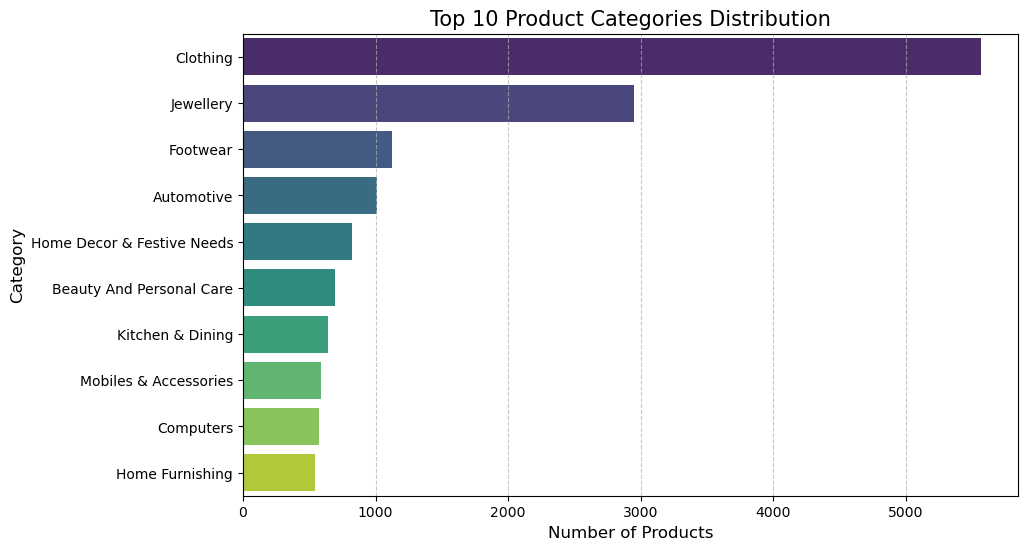

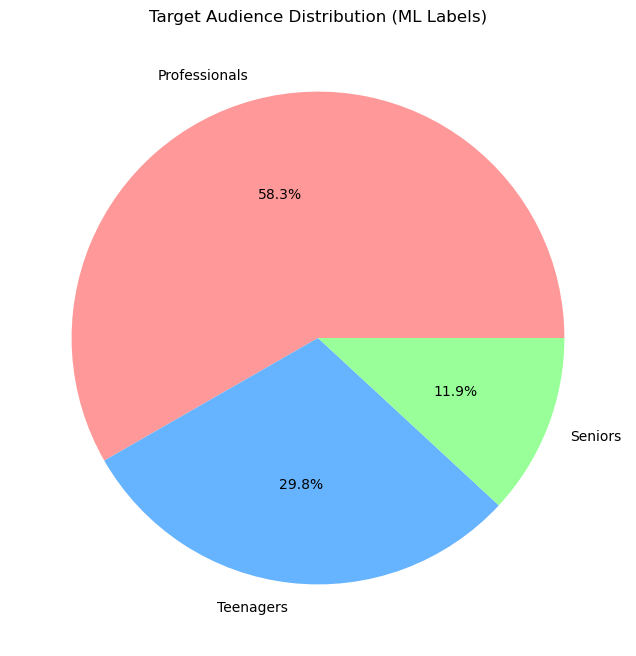

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 categories ka distribution plot karein
plt.figure(figsize=(10, 6))
top_categories = df_clean['main_category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')

plt.title('Top 10 Product Categories Distribution', fontsize=15)
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Audience distribution ka Pie Chart
plt.figure(figsize=(8, 8))
df_clean['target_audience'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Target Audience Distribution (ML Labels)')
plt.ylabel('')
plt.show()


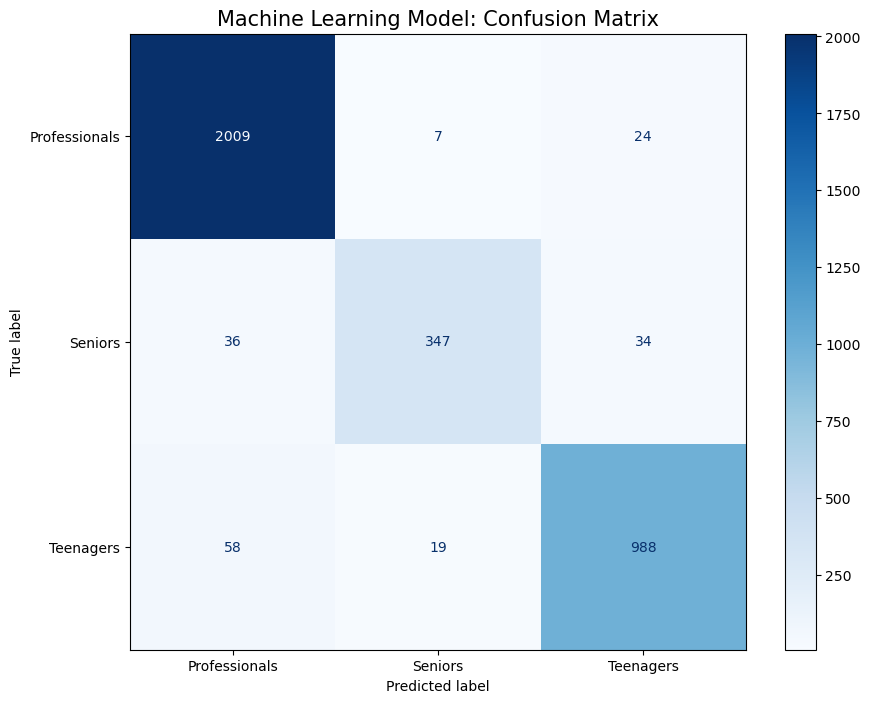

✅ Analytics graphs successfully generated!


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix generate karein
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ml_pipeline.classes_)

# Heatmap plot karein
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax)
plt.title('Machine Learning Model: Confusion Matrix', fontsize=15)
plt.show()

print("✅ Analytics graphs successfully generated!")
